In [1]:
import sys, os
sys.path.append(os.path.
    
    
    abspath('../../'))

In [2]:
import setup_path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import string
from src.utils.graphs import error_line_graph

In [3]:
labels = ['UP', 'UP_LR', 'UP_WS', 'UP_WS_LR']
labels1 = ['UP', 'UP_LR', 'UP_WS', 'UP_LR_WS']
markers = ['.', '.', '*', '*']
lss = ['-', '--', '-', '--']
data_dict = {}

with open("MCLP_Ns_data6_p_50_1000.txt", "r") as file:
    loaded_data = eval(file.read())

n_qubits = [loaded_data[label]['n_qubits'] for label in labels]
data_dict['r_total'] = [loaded_data[label]['r'] for label in labels]
data_dict['probs'] = [loaded_data[label]['probs'] for label in labels]
data_dict['qaoa_FR'] = [loaded_data[label]['qaoa_FR'] for label in labels]
data_dict['t_total'] = [loaded_data[label]['t_total'] for label in labels]
data_dict['n_fev'] = [loaded_data[label]['n_fev'] for label in labels]
success_c = [loaded_data[label]['success_counter'] for label in labels]

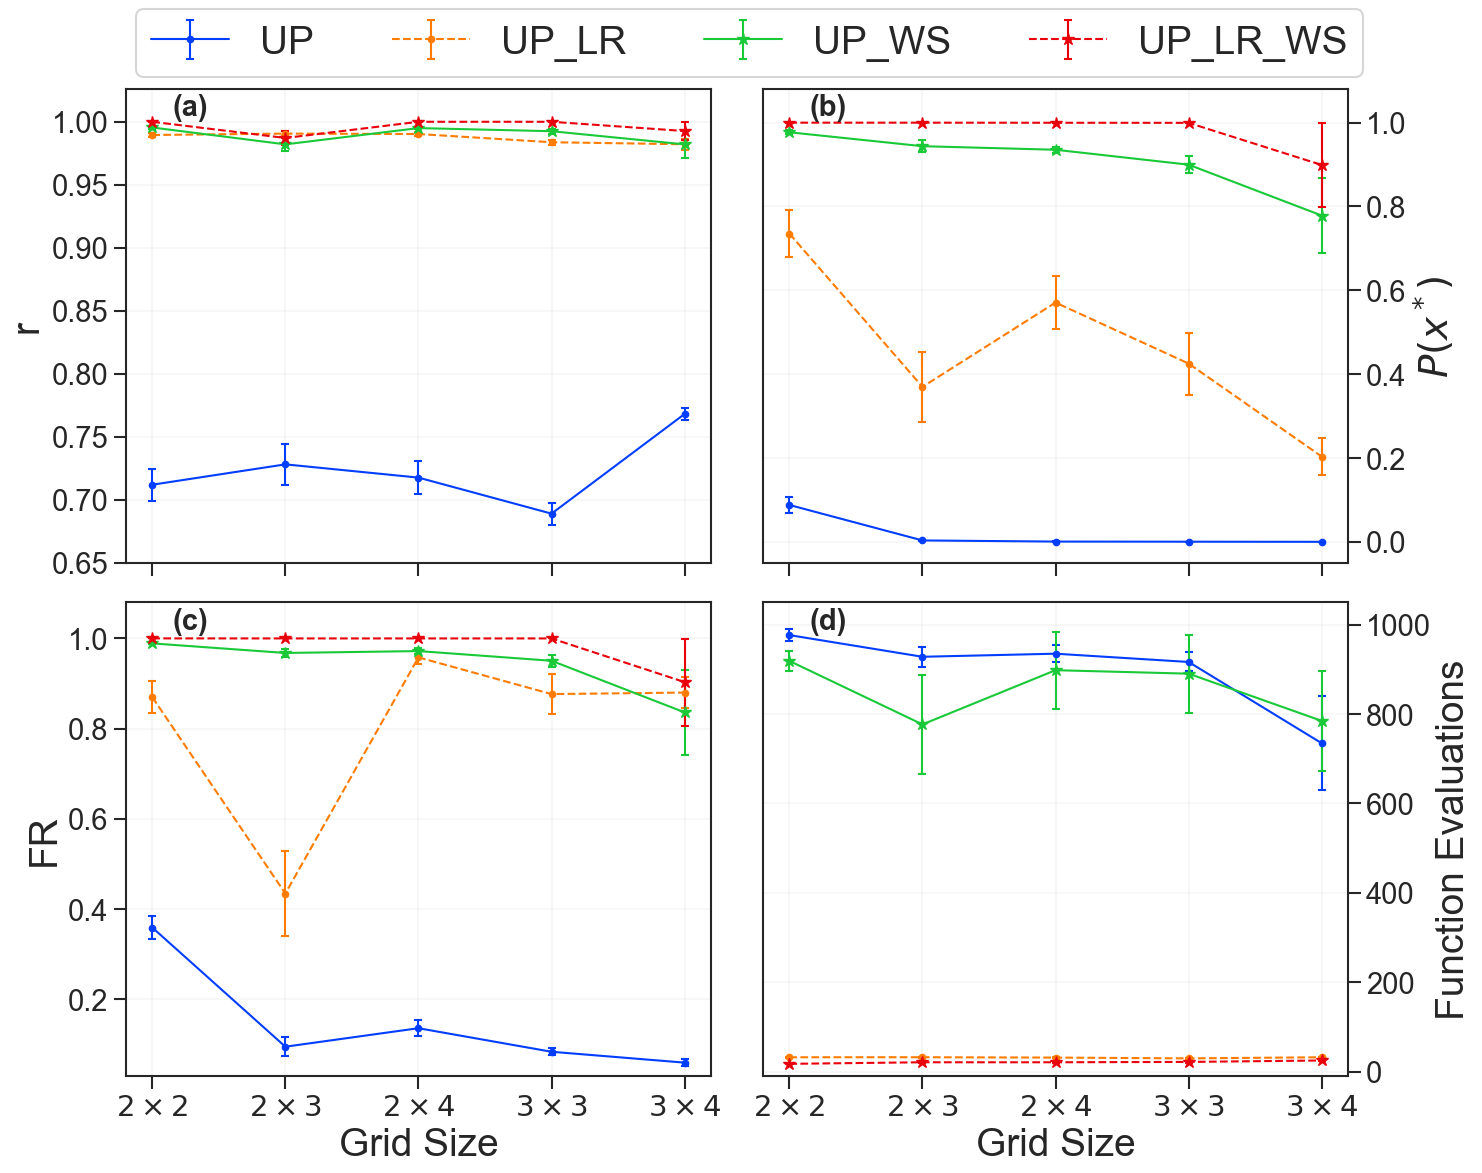

In [8]:
x = [[r'$2 \times 2$', r'$2 \times 3$', r'$2 \times 4$', r'$3 \times 3$', r'$3 \times 4$'] for _ in range(len(labels))]
#x = n_assets
raw_data = data_dict
labels = labels
title = ''
y_label = ''
x_label = 'Grid Size'

font_s=28
label_s=21

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

error_line_graph(axs[0], x, raw_data['r_total'], labels, title, x_label, y_label, markers, lss)
axs[0].set_ylabel('r', fontsize=font_s)
axs[0].minorticks_off()
axs[0].set_ylim([0.65, 1.026])
axs[0].tick_params(bottom=True, labelbottom=False, left=True, labelleft=True, labelsize=label_s)

error_line_graph(axs[1], x, raw_data['probs'], labels, title, x_label, y_label, markers, lss)
axs[1].set_ylabel(r'$P(x^*)$', fontsize=font_s)
axs[1].yaxis.tick_right()  
axs[1].yaxis.set_label_position("right") 
axs[1].minorticks_off()
axs[1].set_ylim([-0.05, 1.08])
axs[1].tick_params(bottom=True, labelbottom=False, left=False, right=True, labelright=True, labelleft=False, labelsize=label_s)

error_line_graph(axs[2], x, raw_data['qaoa_FR'], labels, title, x_label, y_label, markers, lss)
axs[2].tick_params(labelleft=True)
axs[2].tick_params(left=True, labelleft=True)
axs[2].set_ylabel('FR', fontsize=font_s)
axs[2].set_xlabel(x_label, fontsize=font_s)
axs[2].set_ylim([0.03, 1.08])
axs[2].tick_params(labelsize=label_s)

error_line_graph(axs[3], x, raw_data['n_fev'], labels, title, x_label, y_label, markers, lss)
axs[3].set_ylabel('Function Evaluations', fontsize=font_s)
axs[3].yaxis.tick_right()  
axs[3].yaxis.set_label_position("right") 
#axs[3].set_yscale('log')
axs[3].set_xlabel(x_label, fontsize=font_s)
axs[3].set_ylim([-10, 1050])
axs[3].tick_params(left=False, right=True, labelright=True, labelleft=False, labelsize=label_s)

for i in range(4):
    axs[i].grid(linewidth=0.2)

letters = [f"({l})" for l in string.ascii_lowercase[:len(axs)]]
for ax, letter in zip(axs, letters):
    ax.text(0.08, 0.99, letter, transform=ax.transAxes,
        fontsize=21, fontweight='bold', va='top', ha='left')

fig.legend(
    labels1,
    frameon=True,
    fontsize=font_s,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=8
)

plt.tight_layout(rect=[0, 0, 1, 0.94])  # space for legend
plt.savefig('Figure_1.pdf', dpi=300)
plt.show()

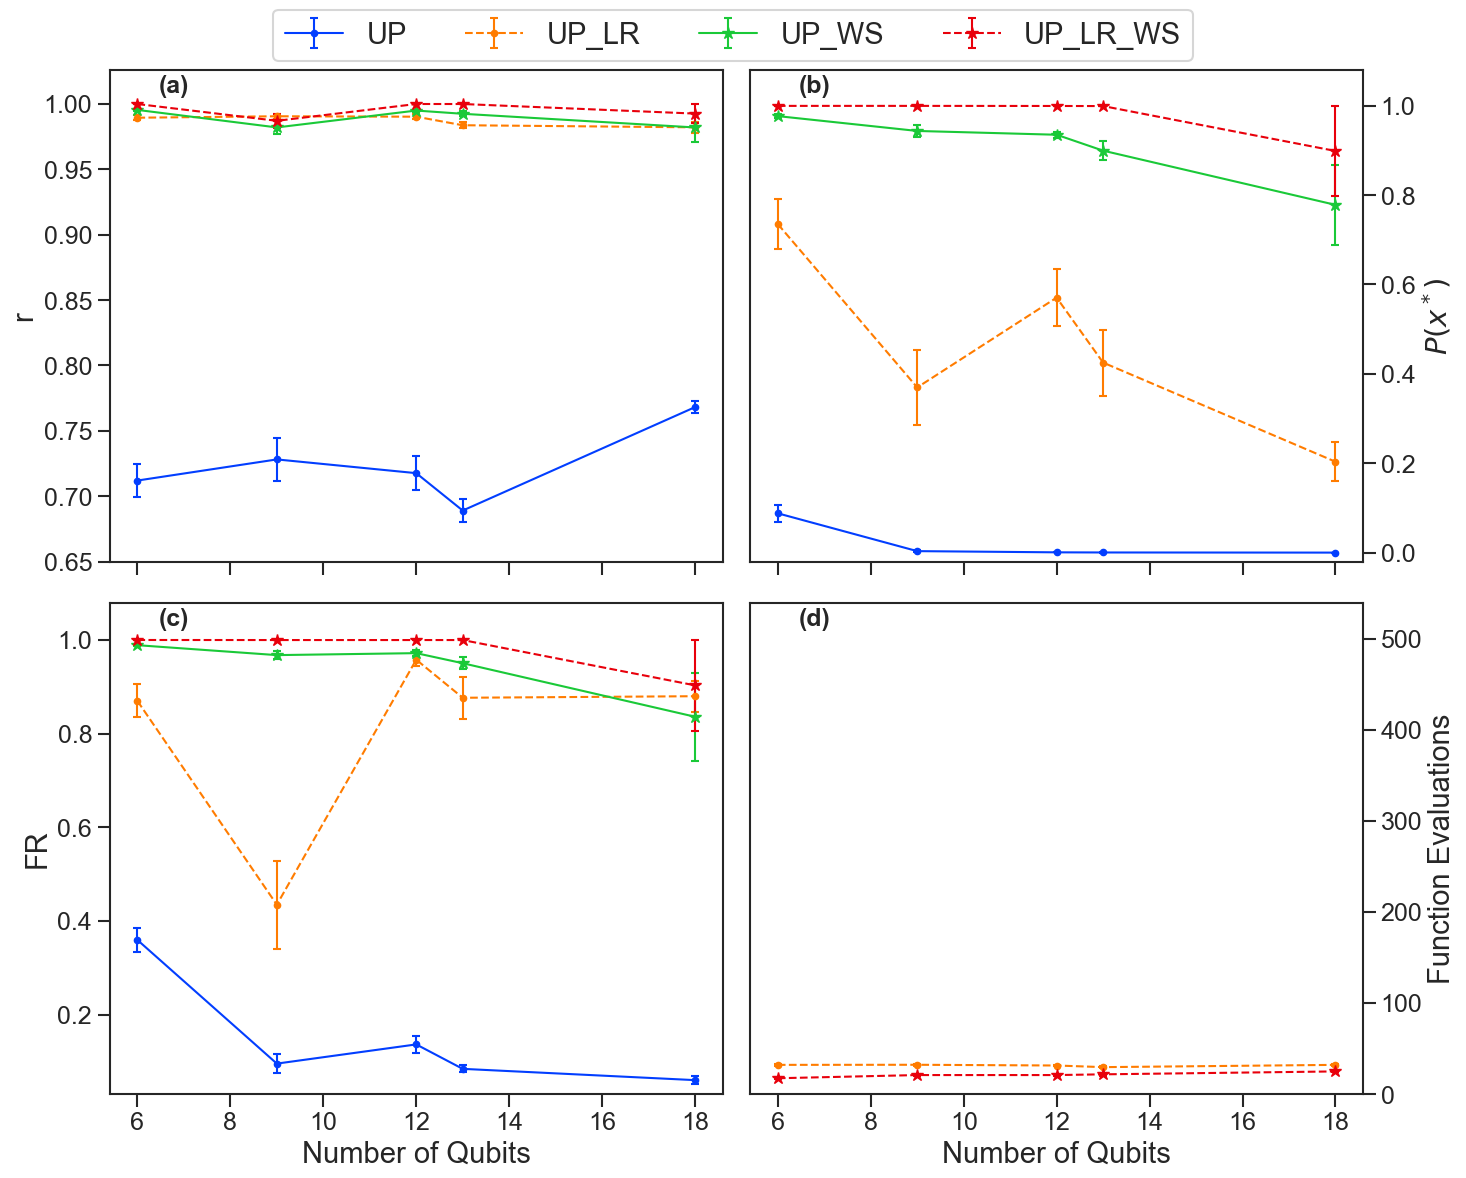

In [5]:
#x = [[r'$2 \times 2$', r'$2 \times 3$', r'$2 \times 4$', r'$3 \times 3$', r'$3 \times 4$'] for _ in range(len(labels))]
x = n_qubits
raw_data = data_dict
labels = labels
title = ''
y_label = ''
x_label = 'Number of Qubits'

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

error_line_graph(axs[0], x, raw_data['r_total'], labels, title, x_label, y_label, markers, lss)
axs[0].set_ylabel('r', fontsize=21)
axs[0].minorticks_off()
axs[0].set_ylim([0.65, 1.026])
axs[0].tick_params(bottom=True, labelbottom=False, left=True, labelleft=True, labelsize=18)

error_line_graph(axs[1], x, raw_data['probs'], labels, title, x_label, y_label, markers, lss)
axs[1].set_ylabel(r'$P(x^*)$', fontsize=21)
axs[1].yaxis.tick_right()  
axs[1].yaxis.set_label_position("right") 
axs[1].minorticks_off()
axs[1].set_ylim([-0.02, 1.08])
axs[1].tick_params(bottom=True, labelbottom=False, left=False, right=True, labelright=True, labelleft=False, labelsize=18)

error_line_graph(axs[2], x, raw_data['qaoa_FR'], labels, title, x_label, y_label, markers, lss)

axs[2].tick_params(labelleft=True)
axs[2].tick_params(left=True, labelleft=True)
axs[2].set_ylabel('FR', fontsize=21)
axs[2].set_xlabel(x_label, fontsize=21)
axs[2].set_ylim([0.03, 1.08])
axs[2].tick_params(labelsize=18)

error_line_graph(axs[3], x, raw_data['n_fev'], labels, title, x_label, y_label, markers, lss)
axs[3].set_ylabel('Function Evaluations', fontsize=21)
axs[3].yaxis.tick_right()  
axs[3].yaxis.set_label_position("right") 
#axs[3].set_yscale('log')
axs[3].set_xlabel(x_label, fontsize=21)
axs[3].set_ylim([0, 540])
axs[3].tick_params(left=False, right=True, labelright=True, labelleft=False, labelsize=18)


letters = [f"({l})" for l in string.ascii_lowercase[:len(axs)]]
for ax, letter in zip(axs, letters):
    ax.text(0.08, 0.99, letter, transform=ax.transAxes,
        fontsize=18, fontweight='bold', va='top', ha='left')

fig.legend(
    labels1,
    frameon=True,
    fontsize=21,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=8
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # space for legend
plt.savefig('Figure_1_1.pdf', dpi=300)
plt.show()